In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

Load data

In [2]:
responses = pd.read_csv("../../data/raw/counterfactual_responses_raw.csv")
metadata = pd.read_csv("../../data/raw/metadata_raw.csv")

Previous cleaning steps

In [3]:
responses["Response"] = responses["Response"].str.strip()

responses = responses.rename(columns= {"Partcipant_ID": "Participant_ID"})

Slice by focus: "readers" or "other-focus"

In [4]:
responses_focus = responses[responses["Focus"] == "They"].copy()

Overall response distribution

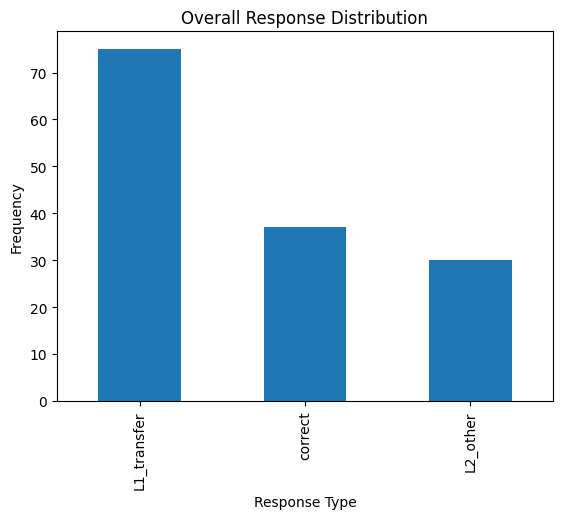

In [6]:
responses_focus["Response"].value_counts().plot(kind ="bar")

plt.title("Overall Response Distribution")
plt.xlabel("Response Type")
plt.ylabel("Frequency")
plt.show()

Counts and Proportions

In [7]:
pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"]
)

Response,L1_transfer,L2_other,correct
Goal_Type,,,
goal_frequent,22,10,16
goal_non_frequent,30,6,11
no_goal,23,14,10


<Axes: xlabel='Goal_Type'>

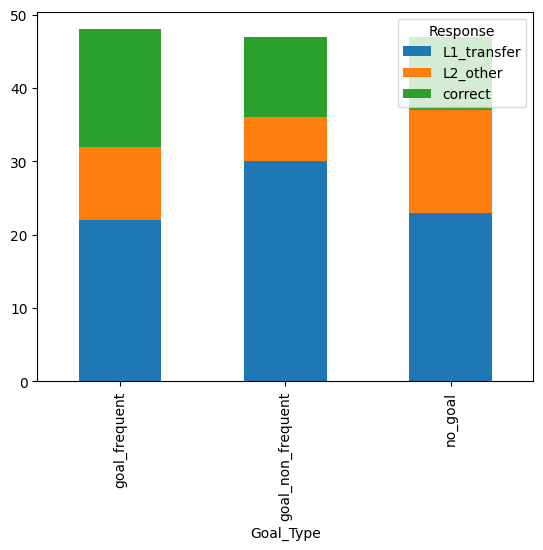

In [8]:
pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"]
).plot(kind="bar", stacked= True)

Response counts with null values

In [9]:
goal_reponse_counts = pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"],
    dropna= False
)

goal_reponse_counts

Response,L1_transfer,L2_other,correct,NaN
Goal_Type,,,,
goal_frequent,22,10,16,0
goal_non_frequent,30,6,11,1
no_goal,23,14,10,1


Response proportions with null values

In [10]:
goal_reponse_props = pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"],
    normalize= "index",
    dropna= False
)

goal_reponse_props

Response,L1_transfer,L2_other,correct,NaN
Goal_Type,,,,
goal_frequent,0.458333,0.208333,0.333333,0.000000
goal_non_frequent,0.625000,0.125000,0.229167,0.020833
no_goal,0.479167,0.291667,0.208333,0.020833


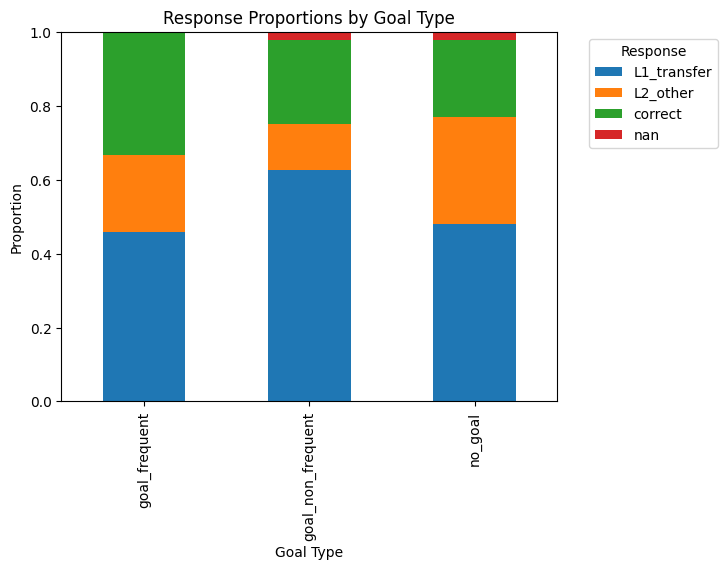

In [11]:
goal_reponse_props.plot(kind= "bar", stacked= True)

plt.title("Response Proportions by Goal Type")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title= "Response", bbox_to_anchor= (1.05,1), loc = "upper left")
plt.show()

Response distribution by agent

In [12]:
agent_response_props = pd.crosstab(
    responses_focus["Agent"],
    responses_focus["Response"],
    normalize= "index",
    dropna= False
)

agent_response_props

Response,L1_transfer,L2_other,correct,NaN
Agent,,,,
0,0.476190,0.261905,0.238095,0.02381
1,0.583333,0.133333,0.283333,0.00000


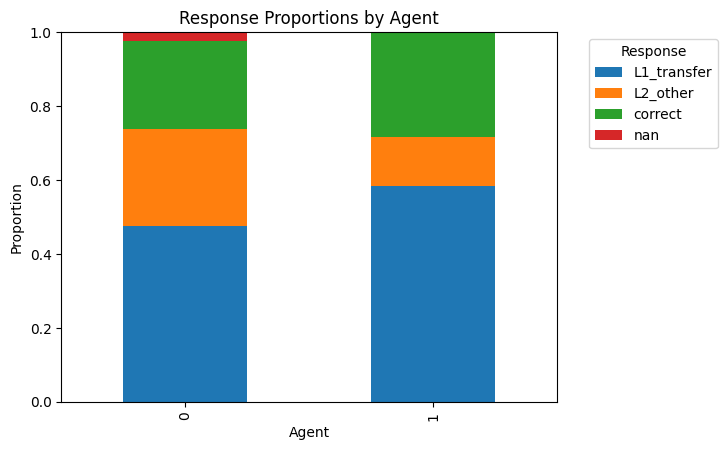

In [13]:
agent_response_props.plot(kind= "bar", stacked= True)

plt.title("Response Proportions by Agent")
plt.xlabel("Agent")
plt.ylabel("Proportion")
plt.legend(title = "Response", bbox_to_anchor =(1.05, 1), loc = "upper left")
plt.show()

Goal Type x Agent interactions

In [14]:
goal_agent_response_props = pd.crosstab(
    [responses_focus["Goal_Type"], responses_focus["Agent"]],
    responses_focus["Response"],
    normalize= "index",
    dropna= False
)

goal_agent_response_props

Response                 L1_transfer  L2_other   correct       NaN
Goal_Type         Agent                                           
goal_frequent     0         0.357143  0.321429  0.321429  0.000000
                  1         0.600000  0.050000  0.350000  0.000000
goal_non_frequent 0         0.642857  0.107143  0.214286  0.035714
                  1         0.600000  0.150000  0.250000  0.000000
no_goal           0         0.428571  0.357143  0.178571  0.035714
                  1         0.550000  0.200000  0.250000  0.000000

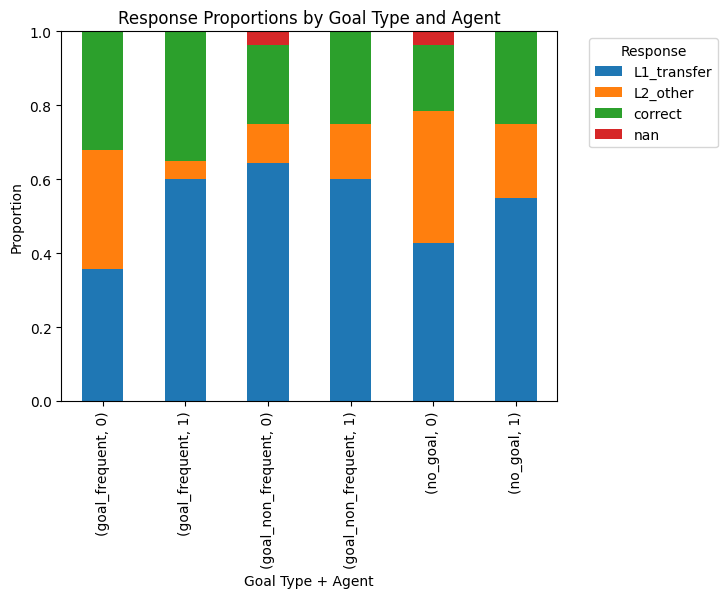

In [15]:
goal_agent_response_props.plot(kind= "bar", stacked= True)

plt.title("Response Proportions by Goal Type and Agent")
plt.xlabel("Goal Type + Agent")
plt.ylabel("Proportion")
plt.legend(title= "Response", bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.show()